In [2]:
# 1. Preparación de los datos multivariantes
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Descargamos y alineamos los datos (como en tu código original)
btc = yf.download('BTC-USD', start='2020-01-01', end='2026-04-01')[['Close']]
eth = yf.download('ETH-USD', start='2020-01-01', end='2026-04-01')[['Close']]
data = pd.concat([btc, eth], axis=1).dropna()
data.columns = ['BTC', 'ETH']



/tmp/ipykernel_1356/1844307448.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download('BTC-USD', start='2020-01-01', end='2026-04-01')[['Close']]
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1356/1844307448.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  eth = yf.download('ETH-USD', start='2020-01-01', end='2026-04-01')[['Close']]
[*********************100%***********************]  1 of 1 completed


In [3]:
# 2. Escalado de datos
# Escalamos cada columna de forma independiente
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)



In [4]:
# 3. Creación de la estructura de datos (Ventana de 60 días)
prediction_days = 60
x_train, y_train = [], []

for x in range(prediction_days, len(scaled_data)):
    # x_train contiene las dos columnas: [BTC, ETH] de los últimos 60 días
    x_train.append(scaled_data[x-prediction_days:x, :])
    # y_train contiene solo el precio de BTC que queremos predecir (columna 0)
    y_train.append(scaled_data[x, 0])

x_train, y_train = np.array(x_train), np.array(y_train)



In [5]:
# 4. Construcción del Modelo LSTM Multivariante
model = Sequential([
    # input_shape ahora es (60, 2) porque usamos 2 variables
    LSTM(units=60, return_sequences=True, input_shape=(x_train.shape[1], 2)),
    Dropout(0.2),
    LSTM(units=60, return_sequences=False),
    Dropout(0.2),
    Dense(units=25),
    Dense(units=1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=30, batch_size=32)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - loss: 0.0137
Epoch 2/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 0.0025
Epoch 3/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - loss: 0.0023
Epoch 4/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 0.0019
Epoch 5/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 0.0018
Epoch 6/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - loss: 0.0018
Epoch 7/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 0.0016
Epoch 8/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 0.0017
Epoch 9/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - loss: 0.0014
Epoch 10/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - loss: 0.0014
Epoch 11/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - loss: 0.0012
Epoch 12/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - loss: 0.0012
Epoch 13/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - loss: 0.0012
Epoch 14/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 0.0013
Epoch 15/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - loss: 0.0011
Epoc

In [6]:

# 5. Predicción del día siguiente
# Tomamos los últimos 60 días de BTC y ETH
last_60_days = scaled_data[-prediction_days:]
last_60_days_reshaped = np.reshape(last_60_days, (1, prediction_days, 2))

prediction_scaled = model.predict(last_60_days_reshaped)

# Para des-escalar la predicción, necesitamos un "scaler" que entienda
# que solo estamos devolviendo 1 valor (BTC)
# Truco rápido: creamos un array dummy para la transformación inversa
dummy = np.zeros((1, 2))
dummy[0, 0] = prediction_scaled
prediction_final = scaler.inverse_transform(dummy)[0, 0]

print(f"\n--- PREDICCIÓN PARA EL PRÓXIMO CIERRE DE BTC ---")
print(f"Precio estimado: ${prediction_final:,.2f} USD")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step

--- PREDICCIÓN PARA EL PRÓXIMO CIERRE DE BTC ---
Precio estimado: $65,666.57 USD


/tmp/ipykernel_1356/208784391.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dummy[0, 0] = prediction_scaled


70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


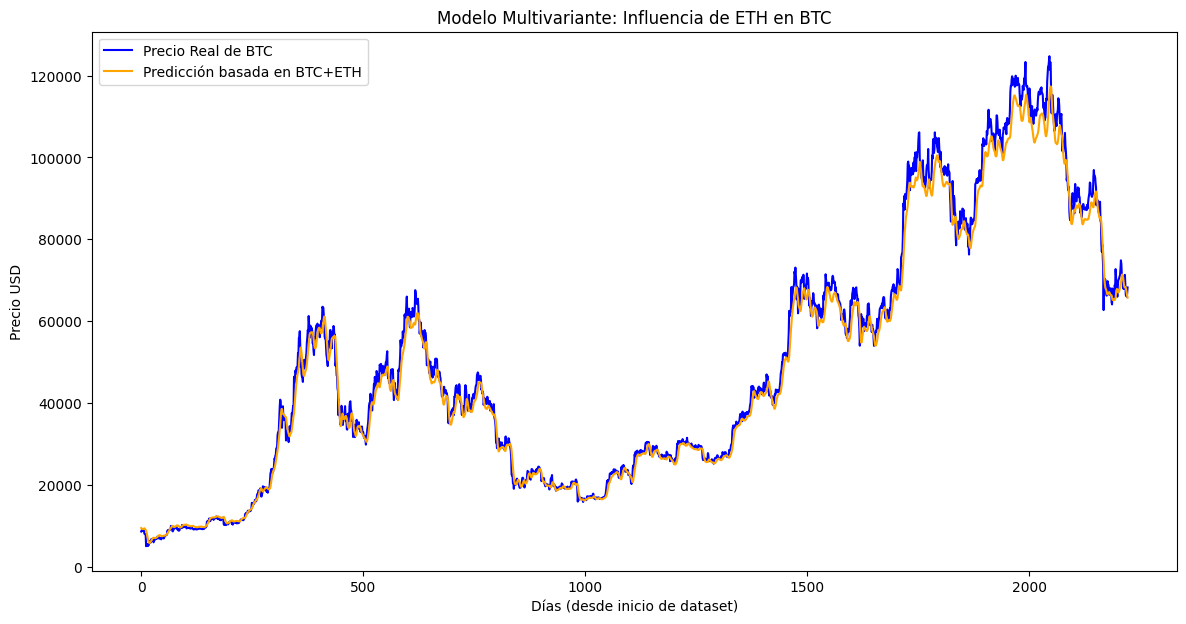

In [7]:

# 6. Gráfica de validación
train_predictions = model.predict(x_train)
# Des-escalar para graficar
dummy_plot = np.zeros((len(train_predictions), 2))
dummy_plot[:, 0] = train_predictions.flatten()
predicted_btc = scaler.inverse_transform(dummy_plot)[:, 0]

real_btc = data['BTC'].values[prediction_days:]

plt.figure(figsize=(14,7))
plt.plot(real_btc, color='blue', label='Precio Real de BTC')
plt.plot(predicted_btc, color='orange', label='Predicción basada en BTC+ETH')
plt.title('Modelo Multivariante: Influencia de ETH en BTC')
plt.xlabel('Días (desde inicio de dataset)')
plt.ylabel('Precio USD')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━

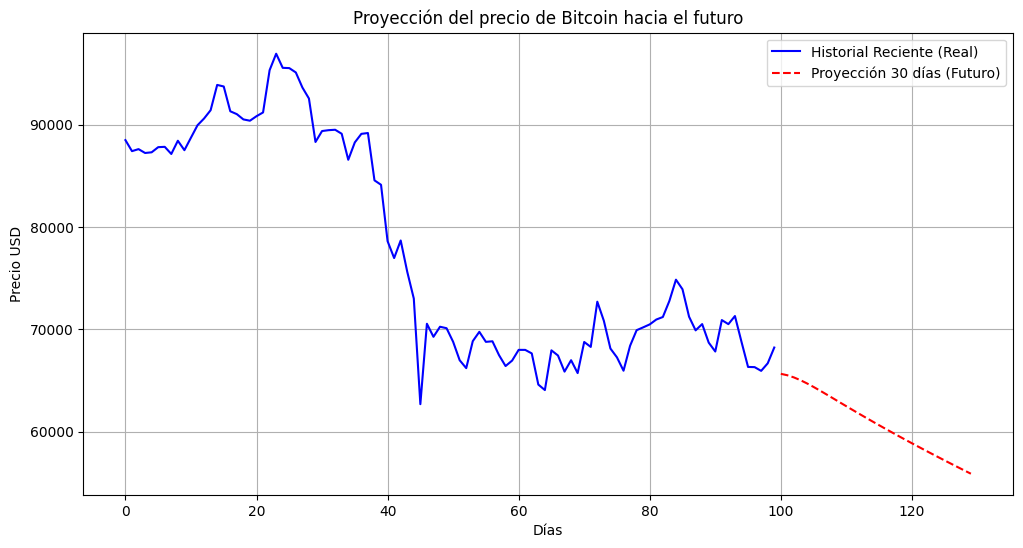

Precio proyectado en 30 días: $55,909.19 USD


In [8]:
# --- PREDICCIÓN DE FUTURO (PRÓXIMOS 30 DÍAS) ---

# 1. Tomamos el último bloque de 60 días de nuestros datos actuales
ultimo_bloque = scaled_data[-prediction_days:]
datos_futuros = []

# Copia para no alterar el original
bloque_actual = ultimo_bloque.reshape(1, prediction_days, 2)

for i in range(30):  # Queremos predecir 30 días al futuro
    # El modelo predice el siguiente valor de BTC
    prediccion_siguiente = model.predict(bloque_actual)

    # Guardamos la predicción
    datos_futuros.append(prediccion_siguiente[0, 0])

    # ACTUALIZAMOS EL BLOQUE:
    # Para la siguiente predicción, necesitamos un nuevo bloque de 60 días.
    # Desplazamos el bloque: quitamos el primer día y añadimos la predicción al final.
    # Nota: Como no sabemos el precio futuro de ETH, asumiremos que se mantiene estable
    # o sigue la tendencia (usamos el último valor de ETH conocido para completar el par)
    last_eth_value = bloque_actual[0, -1, 1]
    nuevo_paso = np.array([[prediccion_siguiente[0, 0], last_eth_value]])
    nuevo_paso = nuevo_paso.reshape(1, 1, 2)

    # Concatenamos el nuevo paso y quitamos el más viejo
    bloque_actual = np.append(bloque_actual[:, 1:, :], nuevo_paso, axis=1)

# 2. Des-escalar los resultados para volver a USD
datos_futuros = np.array(datos_futuros).reshape(-1, 1)
dummy_futuro = np.zeros((30, 2))
dummy_futuro[:, 0] = datos_futuros.flatten()
precios_futuros_usd = scaler.inverse_transform(dummy_futuro)[:, 0]

# 3. Graficar la proyección futura
plt.figure(figsize=(12,6))
dias_pasados = np.arange(100) # Mostramos los últimos 100 días para contexto
dias_futuros = np.arange(100, 130) # Los 30 días de predicción

# Mostramos un trozo del pasado real
plt.plot(dias_pasados, data['BTC'].values[-100:], label='Historial Reciente (Real)', color='blue')

# Mostramos la proyección al futuro
plt.plot(dias_futuros, precios_futuros_usd, label='Proyección 30 días (Futuro)', color='red', linestyle='--')

plt.title('Proyección del precio de Bitcoin hacia el futuro')
plt.xlabel('Días')
plt.ylabel('Precio USD')
plt.legend()
plt.grid(True)
plt.show()

print(f"Precio proyectado en 30 días: ${precios_futuros_usd[-1]:,.2f} USD")


EVALUACIÓN DEL MODELO (Cálculo de MAE)
Horizonte    | Predicción Futura  | MAE (Error) 
--------------------------------------------------
1 día(s)     | $     65,666.57 | $  2,210.58
5 día(s)     | $     64,728.31 | $  3,002.66
10 día(s)     | $     62,880.50 | $  5,065.18
15 día(s)     | $     61,008.69 | $  7,724.97


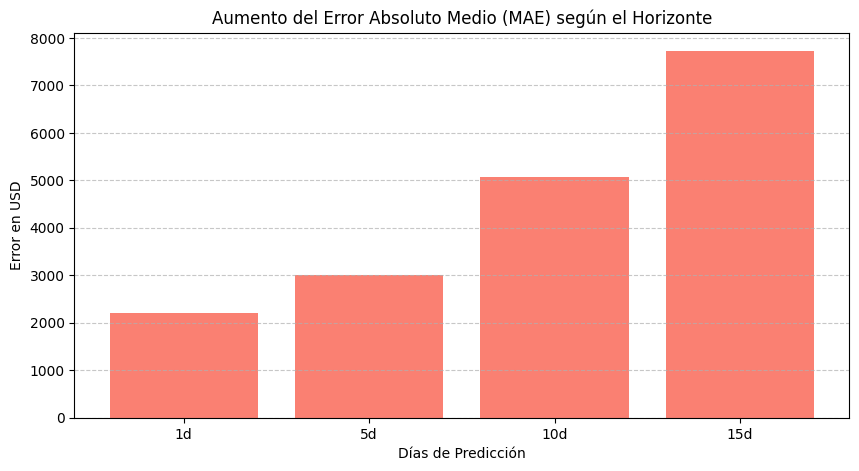

In [9]:
from sklearn.metrics import mean_absolute_error

# 1. Definición de Horizontes y variables de control
horizontes = [1, 5, 10, 15]
mae_resultados = {}

print("\n" + "="*50)
print("EVALUACIÓN DEL MODELO (Cálculo de MAE)")
print("="*50)

# 2. Función de Backtesting para calcular el error real
def evaluar_mae(modelo, data_escalada, h, scaler):
    errores = []
    # Evaluamos en los últimos 20 puntos disponibles para tener una estadística sólida
    for i in range(20, 0, -1):
        # Punto de corte: dejamos 'h' días fuera para comparar la predicción
        fin_entrenamiento = len(data_escalada) - i - h
        if fin_entrenamiento < prediction_days: continue

        # Bloque de entrada (60 días previos al punto de corte)
        bloque = data_escalada[fin_entrenamiento - prediction_days : fin_entrenamiento]
        bloque_actual = bloque.reshape(1, prediction_days, 2)

        # Predicción multi-paso hasta el horizonte h
        for _ in range(h):
            pred_val = modelo.predict(bloque_actual, verbose=0)
            last_eth = bloque_actual[0, -1, 1]
            nuevo_punto = np.array([[pred_val[0,0], last_eth]]).reshape(1,1,2)
            bloque_actual = np.append(bloque_actual[:, 1:, :], nuevo_punto, axis=1)

        # Valor real vs Valor predicho
        real_val_scaled = data_escalada[fin_entrenamiento + h - 1, 0]

        # Des-escalar para obtener dólares
        d_real = np.zeros((1, 2)); d_real[0,0] = real_val_scaled
        d_pred = np.zeros((1, 2)); d_pred[0,0] = pred_val[0,0]

        real_usd = scaler.inverse_transform(d_real)[0,0]
        pred_usd = scaler.inverse_transform(d_pred)[0,0]

        errores.append(abs(real_usd - pred_usd))

    return np.mean(errores)

# 3. Mostrar Resultados en tabla
print(f"{'Horizonte':<12} | {'Predicción Futura':<18} | {'MAE (Error)':<12}")
print("-" * 50)

for h in horizontes:
    # Precio de la línea roja que ya calculaste en tu código anterior
    precio_futuro = precios_futuros_usd[h-1]
    # Calculamos el error promedio para ese horizonte
    error_mae = evaluar_mae(model, scaled_data, h, scaler)

    mae_resultados[h] = error_mae
    print(f"{h} día(s)     | ${precio_futuro:>14,.2f} | ${error_mae:>10,.2f}")

# 4. Gráfica de Barras para el MAE
plt.figure(figsize=(10,5))
plt.bar([f"{h}d" for h in horizontes], list(mae_resultados.values()), color='salmon')
plt.title('Aumento del Error Absoluto Medio (MAE) según el Horizonte')
plt.ylabel('Error en USD')
plt.xlabel('Días de Predicción')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()